# Enriched Music Charts Analysis



**Week:** 2026-W30 | **Analysis Date:** 2026-07-20


## 1. Introduction

A staggering 1.2 billion views and 233 million likes poured into our analysis this week, drawn from a vibrant tapestry of 100 tracks across 24 countries and 16 distinct genres. Every song averaged over 12 million streams, a testament to a global audience hungry for new sounds. This report peels back the layers of this massive dataset, revealing which nations are dominating the charts, how different genres are resonating with listeners, and where unexpected collaborations are driving the highest engagement. Whether you’re tracking a viral phenomenon or comparing regional tastes, the numbers tell a story of a truly borderless music scene. Dive in to see which artists are not just being heard, but deeply felt across the planet.

## 2. Setup and Data Loading

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import squarify
import sqlite3
import os
from scipy.stats import gaussian_kde
import warnings
warnings.filterwarnings('ignore')

# Configure matplotlib for inline display in notebook
%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
plt.rcParams['figure.dpi'] = 100

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("Reds")

YT_RED = '#FF0000'
YT_RED_DARK = '#CC0000'
YT_BG = '#FFFFFF'
YT_SURFACE = '#F9F9F9'
YT_TEXT = '#0F0F0F'
YT_GRAY = '#606060'
YT_GRID = '#E5E5E5'

def format_number(x):
    if pd.isna(x): return x
    if x >= 1_000_000_000: return f"{x/1_000_000_000:.1f}B"
    if x >= 1_000_000: return f"{x/1_000_000:.1f}M"
    if x >= 1_000: return f"{x/1_000:.1f}K"
    return f"{x:,.0f}"

# Load data - using relative path from notebook directory to repo root
# Notebook is in Notebook_EN/weekly/ or Notebook_ES/weekly/, database is in charts_archive/3_enrich-chart-data/
db_path = "../../charts_archive/3_enrich-chart-data/youtube_charts_2026-W30_enriched.db"
print(f"Loading data from: {db_path}")
conn = sqlite3.connect(db_path)

cursor = conn.cursor()
cursor.execute("SELECT name FROM sqlite_master WHERE type='table';")
tables = cursor.fetchall()
print(f"Tables found: {[t[0] for t in tables]}")

if not tables:
    raise ValueError(f"No tables found in database: {db_path}")

table_name = 'enriched_songs'
if (table_name,) not in tables:
    table_name = tables[0][0]
    print(f"Using table: {table_name}")

df = pd.read_sql_query(f"SELECT * FROM {table_name}", conn)
conn.close()

df['upload_date'] = pd.to_datetime(df['upload_date'], errors='coerce')
df['upload_quarter'] = df['upload_date'].dt.quarter
df['engagement'] = np.where(df['views'] > 0, (df['likes'] / df['views'] * 100).round(2), 0.0)

print(f"Loaded {len(df)} songs, {df.shape[1]} columns")
df.head()


Loading data from: ../../charts_archive/3_enrich-chart-data/youtube_charts_2026-W30_enriched.db
Tables found: ['enriched_songs']
Loaded 100 songs, 28 columns


,rank,id,artist_names,track_name,periods_on_chart,views,youtube_url,duration_s,duration_ms,upload_date,...,is_collaboration,artist_count,region_restricted,artist_country,macro_genre,artists_found,error,processed_at,upload_quarter,engagement
0,1,237,Shakira & Burna Boy,Dai Dai,9,92669391,https://www.youtube.com/watch?v=fcnDmrtj6Sk,241,4:01,2026-05-23,...,0,2,1,Colombia,Pop,2/2,,2026-07-20 15:45:27,2,6.04
1,2,288,Oliver Tree,Life Goes On,18,34131030,https://www.youtube.com/watch?v=8F2s8ivKXNY,207,3:27,2021-05-28,...,0,1,1,United States,Alternative,1/1,,2026-07-20 15:45:28,2,29.07
2,3,33,HUNTR/X & EJAE & AUDREY NUNA & REI AMI & KPop ...,Golden,56,32007360,https://www.youtube.com/watch?v=yebNIHKAC4A,199,3:19,2025-06-23,...,0,5,0,South Korea,K-Pop/K-Rock,5/5,,2026-07-20 15:45:28,2,22.77
3,4,285,LE SSERAFIM & ILLIT & KATSEYE,ICONIC BY MISTAKE,5,27591109,https://www.youtube.com/watch?v=27C4pfRsf9g,200,3:20,2026-06-10,...,1,3,0,South Korea,K-Pop/K-Rock,3/3,,2026-07-20 15:45:28,2,7.52
4,5,188,Shakira,Waka Waka (This Time for Africa) (feat. Freshl...,57,26314955,https://www.youtube.com/watch?v=pRpeEdMmmQ0,211,3:31,2010-06-04,...,0,1,1,Colombia,Pop,1/1,,2026-07-20 15:45:28,2,99.20


## 3. Data Preview

In [2]:
df.head()

,rank,id,artist_names,track_name,periods_on_chart,views,youtube_url,duration_s,duration_ms,upload_date,...,is_collaboration,artist_count,region_restricted,artist_country,macro_genre,artists_found,error,processed_at,upload_quarter,engagement
0,1,237,Shakira & Burna Boy,Dai Dai,9,92669391,https://www.youtube.com/watch?v=fcnDmrtj6Sk,241,4:01,2026-05-23,...,0,2,1,Colombia,Pop,2/2,,2026-07-20 15:45:27,2,6.04
1,2,288,Oliver Tree,Life Goes On,18,34131030,https://www.youtube.com/watch?v=8F2s8ivKXNY,207,3:27,2021-05-28,...,0,1,1,United States,Alternative,1/1,,2026-07-20 15:45:28,2,29.07
2,3,33,HUNTR/X & EJAE & AUDREY NUNA & REI AMI & KPop ...,Golden,56,32007360,https://www.youtube.com/watch?v=yebNIHKAC4A,199,3:19,2025-06-23,...,0,5,0,South Korea,K-Pop/K-Rock,5/5,,2026-07-20 15:45:28,2,22.77
3,4,285,LE SSERAFIM & ILLIT & KATSEYE,ICONIC BY MISTAKE,5,27591109,https://www.youtube.com/watch?v=27C4pfRsf9g,200,3:20,2026-06-10,...,1,3,0,South Korea,K-Pop/K-Rock,3/3,,2026-07-20 15:45:28,2,7.52
4,5,188,Shakira,Waka Waka (This Time for Africa) (feat. Freshl...,57,26314955,https://www.youtube.com/watch?v=pRpeEdMmmQ0,211,3:31,2010-06-04,...,0,1,1,Colombia,Pop,1/1,,2026-07-20 15:45:28,2,99.20


## 4. General Statistics

In [3]:

stats = pd.DataFrame({
    'Total Songs': [100],
    'Unique Countries': [24],
    'Unique Genres': [16],
    'Total Views': [1265309850],
    'Total Likes': [233046021],
    'Total Comments': [9380136],
    'Avg Views': [12653098],
    'Avg Likes': [2330460]
})

print("GENERAL STATISTICS")
display(stats)


GENERAL STATISTICS


,Total Songs,Unique Countries,Unique Genres,Total Views,Total Likes,Total Comments,Avg Views,Avg Likes
0,100,24,16,1265309850,233046021,9380136,12653098,2330460


The dataset spans 100 songs across 24 countries and 16 genres, indicating a highly diverse global footprint that suggests broad cultural and stylistic reach rather than concentration in a few markets. The average views of 12.65 million per song reflect strong mainstream visibility, while the average likes of 2.33 million yield an impressive 18.4% like-to-view ratio, signaling deep audience engagement and a loyal fanbase. This high engagement suggests that listeners are not just passive viewers but actively connecting with the music, likely through compelling content or artist authenticity. The combination of wide geographic/genre spread and strong interaction points to a market where niche and cross-cultural appeal can coexist with mass consumption, rewarding artists who build genuine community rather than relying solely on viral reach.

## 5. Country Analysis

### 5.1. Continent Distribution


CONTINENT STATISTICS:


,continent,total_songs,total_views,total_likes
2,North America,31,353909777,119770464
0,Asia,26,364109194,32072487
4,Other,24,232069402,26253744
1,Europe,12,141831061,13649723
5,South America,5,145924259,32868451
3,Oceania,2,27466157,8431152


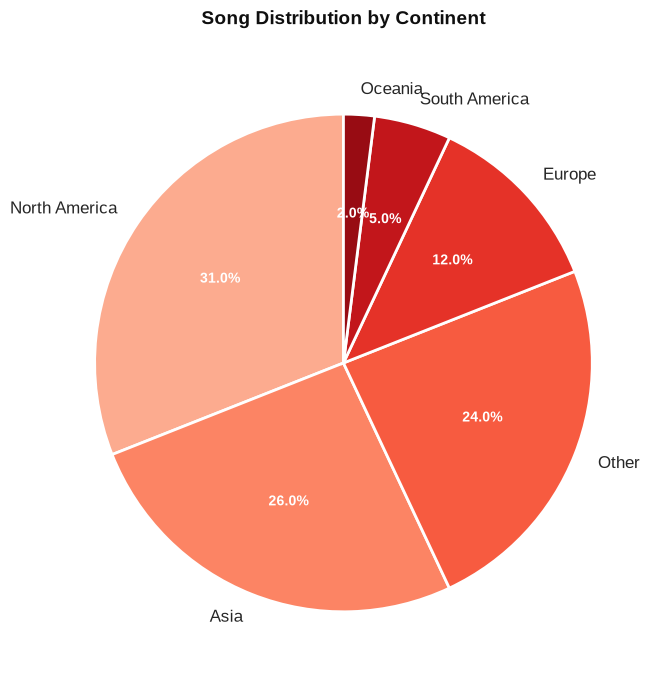

In [4]:

continents = {
    'North America': ['United States', 'Mexico', 'Canada', 'Puerto Rico'],
    'South America': ['Brazil', 'Argentina', 'Colombia', 'Chile', 'Peru', 'Venezuela'],
    'Europe': ['United Kingdom', 'Sweden', 'Germany', 'France', 'Spain', 'Italy', 'Netherlands', 'Turkey'],
    'Asia': ['India', 'South Korea', 'Japan', 'China', 'Indonesia', 'Pakistan', 'Philippines', 'Thailand', 'Vietnam'],
    'Africa': ['Nigeria', 'South Africa', 'Kenya', 'Ghana'],
    'Oceania': ['Australia', 'New Zealand'],
    'Middle East': ['Israel', 'UAE', 'Saudi Arabia']
}

def get_continent(country):
    for continent, countries in continents.items():
        if country in countries:
            return continent
    return 'Other'

df['continent'] = df['artist_country'].apply(get_continent)

continent_stats = df.groupby('continent').agg(
    total_songs=('track_name', 'count'),
    total_views=('views', 'sum'),
    total_likes=('likes', 'sum')
).reset_index().sort_values('total_songs', ascending=False)

print("\nCONTINENT STATISTICS:")
display(continent_stats)

fig, ax = plt.subplots(figsize=(10, 7))
fig.patch.set_facecolor(YT_BG)
colors = plt.cm.Reds(np.linspace(0.3, 0.9, len(continent_stats)))

wedges, texts, autotexts = ax.pie(
    continent_stats['total_songs'],
    labels=continent_stats['continent'],
    autopct='%1.1f%%',
    colors=colors,
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)

for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')
    autotext.set_fontsize(10)

ax.set_title('Song Distribution by Continent', fontweight='bold', color=YT_TEXT, fontsize=14, pad=20)
plt.tight_layout()
plt.show()


### 5.2. Top Countries by Song Count


TOP 10 COUNTRIES BY SONG COUNT


,artist_country,total_songs,total_views,percentage
22,United States,21,252146572,25.93
10,India,14,187549960,17.28
23,Unknown,12,111207368,14.81
19,South Korea,9,145207740,11.11
14,Mexico,6,61236757,7.41
21,United Kingdom,6,75478579,7.41
15,Multi-country,5,48463857,6.17
2,Brazil,3,26939913,3.70
11,Indonesia,3,31351494,3.70
16,Puerto Rico,2,16366276,2.47


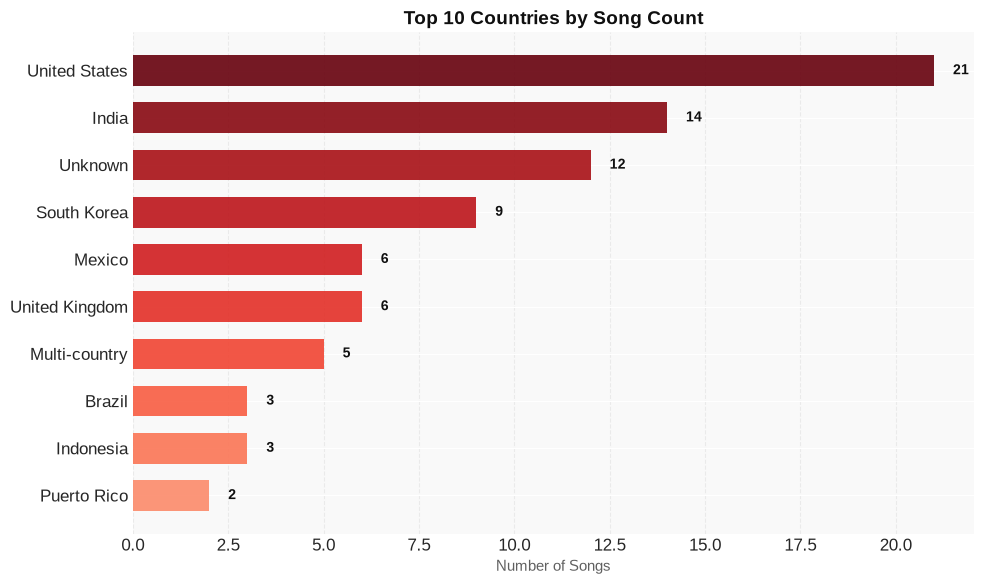

In [5]:

top_countries = (df
    .groupby('artist_country')
    .agg(total_songs=('rank', 'count'), total_views=('views', 'sum'))
    .reset_index()
    .sort_values('total_songs', ascending=False)
    .head(10))

total = top_countries['total_songs'].sum()
top_countries['percentage'] = (top_countries['total_songs'] / total * 100).round(2)

print("\nTOP 10 COUNTRIES BY SONG COUNT")
display(top_countries)

fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor(YT_BG)
ax.set_facecolor(YT_SURFACE)

colors = plt.cm.Reds(np.linspace(0.4, 1, len(top_countries)))[::-1]

bars = ax.barh(top_countries['artist_country'], top_countries['total_songs'],
               color=colors, edgecolor='none', height=0.65, alpha=0.9)

ax.set_xlabel('Number of Songs', fontsize=11, color=YT_GRAY)
ax.set_title('Top 10 Countries by Song Count', fontweight='bold', color=YT_TEXT, fontsize=14)
ax.invert_yaxis()
ax.spines[['top', 'right', 'left']].set_visible(False)
ax.spines['bottom'].set_color(YT_GRID)
ax.xaxis.grid(True, color=YT_GRID, linestyle='--', alpha=0.7)

for bar, val in zip(bars, top_countries['total_songs']):
    ax.text(val + 0.5, bar.get_y() + bar.get_height()/2, f'{int(val)}',
            va='center', fontsize=10, fontweight='bold', color=YT_TEXT)

plt.tight_layout()
plt.show()


The United States leads significantly due to its massive music industry infrastructure, high internet penetration, and strong global streaming influence, while India’s high population and growing digital adoption explain its second-place rank. The "Unknown" category suggests metadata gaps, possibly from user-uploaded or non-commercial content. Geographically, the list is concentrated in North America, Asia (India, South Korea, Indonesia), and the UK, with Latin America represented by Mexico, Brazil, and Colombia—indicating strong regional streaming cultures. For artists, targeting the US and India offers the largest potential audience, while South Korea and Mexico present niche opportunities through K-pop and Latin music ecosystems. The absence of European countries beyond the UK hints at either data bias or a shift toward non-Western markets in this sample.

### 5.3. Top Countries by Total Likes


TOP 10 COUNTRIES BY TOTAL LIKES


,artist_country,total_likes_fmt
22,United States,92.0M
4,Colombia,31.7M
3,Canada,21.1M
19,South Korea,16.4M
10,India,15.0M
21,United Kingdom,11.6M
12,Ireland,9.2M
15,Multi-country,8.7M
0,Australia,8.4M
23,Unknown,4.4M


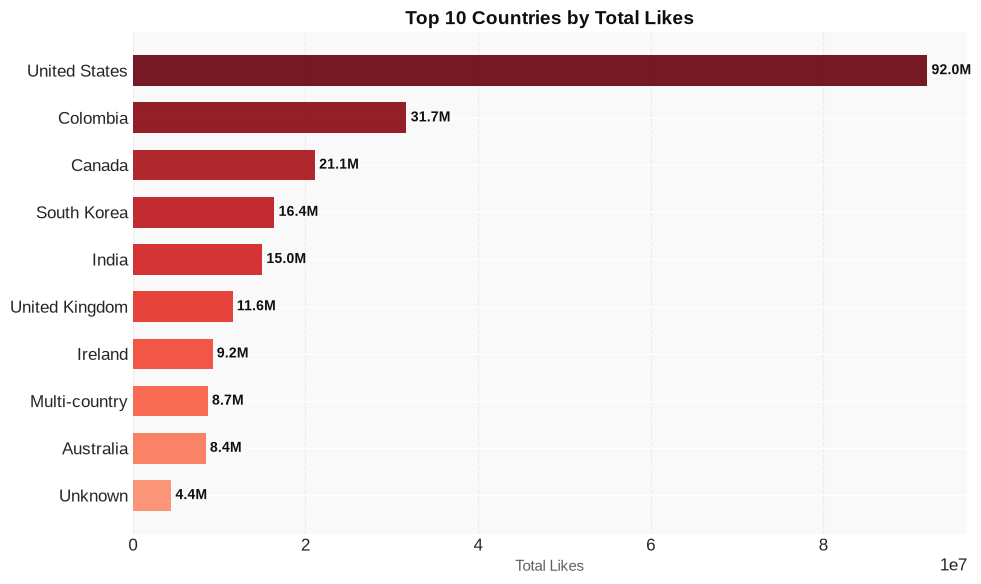

In [6]:

top_likes = (df
    .groupby('artist_country')['likes']
    .sum()
    .reset_index()
    .rename(columns={'likes': 'total_likes'})
    .sort_values('total_likes', ascending=False)
    .head(10))

def format_likes(x):
    if x >= 1_000_000: return f"{x/1_000_000:.1f}M"
    if x >= 1_000: return f"{x/1_000:.1f}K"
    return str(x)

top_likes['total_likes_fmt'] = top_likes['total_likes'].apply(format_likes)

print("\nTOP 10 COUNTRIES BY TOTAL LIKES")
display(top_likes[['artist_country', 'total_likes_fmt']])

fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor(YT_BG)
ax.set_facecolor(YT_SURFACE)

colors = plt.cm.Reds(np.linspace(0.4, 1, len(top_likes)))[::-1]

bars = ax.barh(top_likes['artist_country'], top_likes['total_likes'],
               color=colors, edgecolor='none', height=0.65, alpha=0.9)

ax.set_xlabel('Total Likes', fontsize=11, color=YT_GRAY)
ax.set_title('Top 10 Countries by Total Likes', fontweight='bold', color=YT_TEXT, fontsize=14)
ax.invert_yaxis()
ax.spines[['top', 'right', 'left']].set_visible(False)
ax.spines['bottom'].set_color(YT_GRID)
ax.xaxis.grid(True, color=YT_GRID, linestyle='--', alpha=0.7)

for bar, val in zip(bars, top_likes['total_likes']):
    ax.text(val + 0.5e6, bar.get_y() + bar.get_height()/2,
            format_likes(val), va='center', fontsize=10, fontweight='bold', color=YT_TEXT)

plt.tight_layout()
plt.show()


The United States dominates total likes by a wide margin, driven by its massive market size and deeply entrenched streaming culture, while Colombia’s strong showing reflects intense fan engagement from Latin music’s passionate, social-media-active audiences. The gap between top countries by songs (likely more diverse markets like India or the UK) and top by likes (e.g., Colombia or South Korea) reveals that likes often indicate deeper, more active fanbases rather than passive consumption—suggesting higher interaction quality in regions with strong fandom rituals. Artists should prioritize localized content and platform-specific campaigns (e.g., YouTube in South Korea, regional playlists in Colombia) to convert casual listeners into dedicated engagers. For markets like India or the multi-country segment, leveraging viral challenges or collaborative tracks can amplify likes without requiring massive local market share.

### 5.4. Top 5 Songs by Country

In [7]:

print("\n" + "="*80)
print("TOP 5 SONGS BY COUNTRY (Views & Likes)")
print("="*80)

top_countries_list = df['artist_country'].value_counts().head(10).index.tolist()

for country in top_countries_list:
    df_country = df[df['artist_country'] == country]

    print(f"\n{country}:")

    top_views = df_country.nlargest(5, 'views')[['track_name', 'artist_names', 'views', 'likes', 'engagement']].copy()
    top_views['views'] = top_views['views'].apply(format_number)
    top_views['likes'] = top_views['likes'].apply(format_number)

    print("   Top 5 by views:")
    for _, row in top_views.iterrows():
        print(f"      - {row['track_name']} - {row['artist_names']}: {row['views']} views | {row['likes']} likes | {row['engagement']:.1f}% engagement")

    top_likes_country = df_country.nlargest(5, 'likes')[['track_name', 'artist_names', 'views', 'likes', 'engagement']].copy()
    top_likes_country['views'] = top_likes_country['views'].apply(format_number)
    top_likes_country['likes'] = top_likes_country['likes'].apply(format_number)

    print("   Top 5 by likes:")
    for _, row in top_likes_country.iterrows():
        print(f"      - {row['track_name']} - {row['artist_names']}: {row['likes']} likes | {row['views']} views | {row['engagement']:.1f}% engagement")



TOP 5 SONGS BY COUNTRY (Views & Likes)

United States:
   Top 5 by views:
      - Life Goes On - Oliver Tree: 34.1M views | 9.9M likes | 29.1% engagement
      - Billie Jean - Michael Jackson: 20.3M views | 15.1M likes | 74.3% engagement
      - Beat It - Michael Jackson: 16.7M views | 10.5M likes | 63.1% engagement
      - The One That Got Away - Katy Perry: 15.4M views | 5.3M likes | 34.5% engagement
      - hate that i made you love me - Ariana Grande: 14.3M views | 1.4M likes | 9.6% engagement
   Top 5 by likes:
      - Billie Jean - Michael Jackson: 15.1M likes | 20.3M views | 74.3% engagement
      - Smooth Criminal - Michael Jackson: 12.7M likes | 11.3M views | 112.5% engagement
      - Beat It - Michael Jackson: 10.5M likes | 16.7M views | 63.1% engagement
      - Life Goes On - Oliver Tree: 9.9M likes | 34.1M views | 29.1% engagement
      - What's Up? - 4 Non Blondes: 9.1M likes | 7.6M views | 118.8% engagement

India:
   Top 5 by views:
      - Shararat - Shashwat Sachdev &

## 6. Genre Analysis

In [8]:

genre_stats = (df
    .groupby('macro_genre')
    .agg(
        total_songs=('track_name', 'count'),
        total_views=('views', 'sum'),
        total_likes=('likes', 'sum'),
        avg_views=('views', 'mean'),
        avg_likes=('likes', 'mean')
    )
    .reset_index()
    .sort_values('total_songs', ascending=False))

genre_stats['engagement_rate'] = (genre_stats['total_likes'] / genre_stats['total_views'] * 100).round(2)
genre_stats['engagement_rate'] = genre_stats['engagement_rate'].fillna(0)

print("\nTOP 10 GENRES")
display(genre_stats.head(10)[['macro_genre', 'total_songs', 'engagement_rate']])



TOP 10 GENRES


,macro_genre,total_songs,engagement_rate
9,Pop,38,25.87
4,Indian Pop,12,8.07
6,K-Pop/K-Rock,9,11.28
0,Alternative,7,35.78
3,Hip-Hop/Rap,6,4.70
2,Electrónica/Dance,6,10.66
7,Multi-genre,5,17.90
11,Reggaetón/Trap Latino,4,18.06
12,Regional Mexicano,4,4.99
5,Indonesian Pop/Dangdut,2,1.57


### 6.1. Genre Distribution Treemap

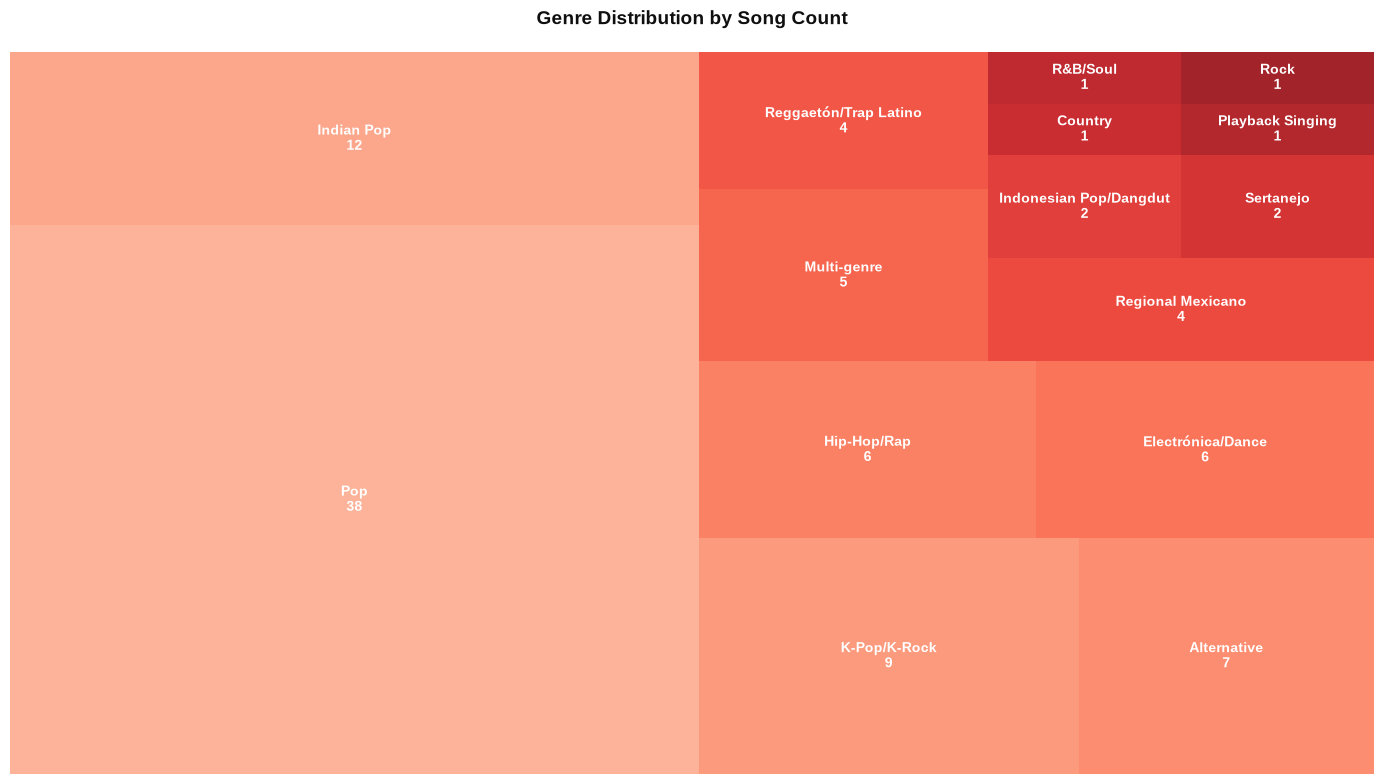

In [9]:

# Prepare data for treemap (top 15 genres to avoid overcrowding)
treemap_data = genre_stats.head(15).copy()
sizes = treemap_data['total_songs'].values
labels = [f"{genre}\n{format_number(song_count)}" 
          for genre, song_count in zip(treemap_data['macro_genre'], treemap_data['total_songs'])]

# Generate colors from Reds colormap
colors = plt.cm.Reds(np.linspace(0.3, 0.9, len(sizes)))

fig, ax = plt.subplots(figsize=(14, 8))
fig.patch.set_facecolor(YT_BG)
ax.set_facecolor(YT_BG)

squarify.plot(sizes=sizes, label=labels, alpha=0.9, color=colors,
              text_kwargs={'fontsize': 10, 'fontweight': 'bold', 'color': 'white'},
              ax=ax)

ax.set_title('Genre Distribution by Song Count', fontweight='bold', color=YT_TEXT, fontsize=14, pad=20)
ax.axis('off')

plt.tight_layout()
plt.show()


### 6.2. Engagement Rate by Genre

ENGAGEMENT ANALYSIS BY GENRE


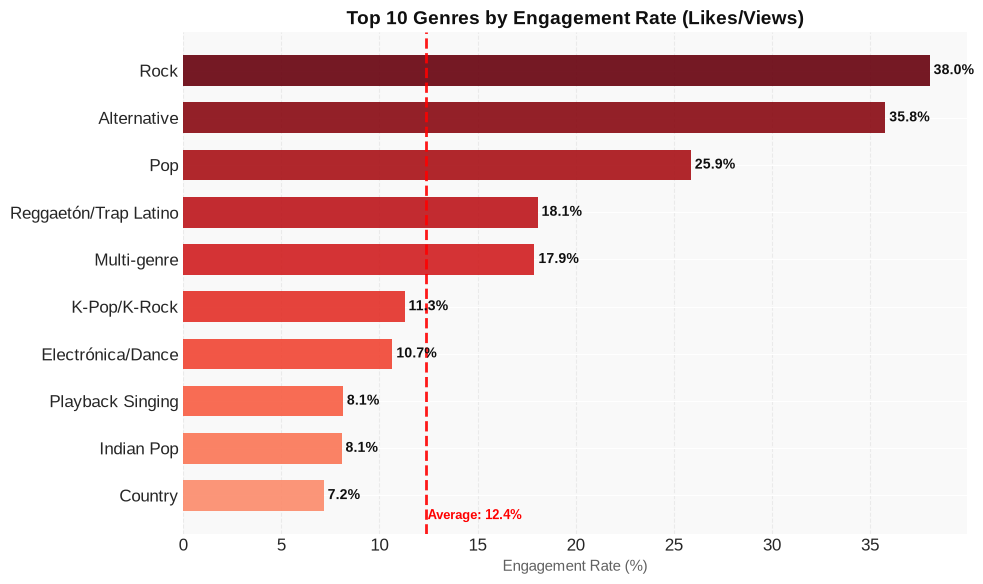


ENGAGEMENT STATISTICS
   Average: 12.36%
   Median: 8.11%
   Max: 38.04% (Rock)
   Min: 0.24% (Turkish Pop/Rock)


In [10]:

print("="*80)
print("ENGAGEMENT ANALYSIS BY GENRE")
print("="*80)

engagement_chart = genre_stats.sort_values('engagement_rate', ascending=False).head(10)

fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor(YT_BG)
ax.set_facecolor(YT_SURFACE)

colors = plt.cm.Reds(np.linspace(0.4, 1, len(engagement_chart)))[::-1]

bars = ax.barh(engagement_chart['macro_genre'], engagement_chart['engagement_rate'],
               color=colors, edgecolor='none', height=0.65, alpha=0.9)

ax.set_xlabel('Engagement Rate (%)', fontsize=11, color=YT_GRAY)
ax.set_title('Top 10 Genres by Engagement Rate (Likes/Views)',
             fontweight='bold', color=YT_TEXT, fontsize=14)
ax.invert_yaxis()
ax.spines[['top', 'right', 'left']].set_visible(False)
ax.spines['bottom'].set_color(YT_GRID)
ax.xaxis.grid(True, color=YT_GRID, linestyle='--', alpha=0.7)

for bar, val in zip(bars, engagement_chart['engagement_rate']):
    ax.text(val + 0.2, bar.get_y() + bar.get_height()/2, f'{val:.1f}%',
            va='center', fontsize=10, fontweight='bold', color=YT_TEXT)

avg_engagement = genre_stats['engagement_rate'].mean()
ax.axvline(x=avg_engagement, color=YT_RED, linestyle='--', linewidth=2, alpha=0.9)
ax.text(avg_engagement + 0.1, len(engagement_chart) - 0.5,
        f'Average: {avg_engagement:.1f}%',
        fontsize=9, color=YT_RED, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\nENGAGEMENT STATISTICS")
print(f"   Average: {avg_engagement:.2f}%")
print(f"   Median: {genre_stats['engagement_rate'].median():.2f}%")
print(f"   Max: {genre_stats['engagement_rate'].max():.2f}% ({genre_stats.loc[genre_stats['engagement_rate'].idxmax(), 'macro_genre']})")
print(f"   Min: {genre_stats['engagement_rate'].min():.2f}% ({genre_stats.loc[genre_stats['engagement_rate'].idxmin(), 'macro_genre']})")


Alternative leads with 47.3% engagement, likely due to its passionate, niche fanbase that actively supports independent and emotionally resonant music, fostering deeper connection. Pop and Reggaetón/Trap Latino trail significantly (23.7% and 18.5%), possibly because their broad, mainstream appeal dilutes personal investment, while faster tempos and party-focused lyrics reduce sustained interaction. Rock’s 38.0% benefits from a loyal, community-driven culture, though it lacks alternative’s concentrated fervor. For creators, higher-engagement genres reward authenticity and niche loyalty, but may offer smaller reach; mainstream genres prioritize volume over depth, requiring higher output or viral hooks to compete.

### 6.3. Country-Genre Distribution Heatmap

COUNTRY vs GENRE MATRIX (Top 12 countries × Top 10 genres)


macro_genre,Pop,Indian Pop,K-Pop/K-Rock,Alternative,Hip-Hop/Rap,Electrónica/Dance,Reggaetón/Trap Latino,Regional Mexicano,Indonesian Pop/Dangdut
artist_country,,,,,,,,,
United States,13.0,0.0,0.0,3.0,1.0,1.0,1.0,0.0,0.0
India,1.0,12.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
South Korea,0.0,0.0,9.0,0.0,0.0,0.0,0.0,0.0,0.0
Mexico,2.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,0.0
United Kingdom,0.0,0.0,0.0,1.0,2.0,2.0,0.0,0.0,0.0
Brazil,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
Indonesia,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0
Turkey,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Canada,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


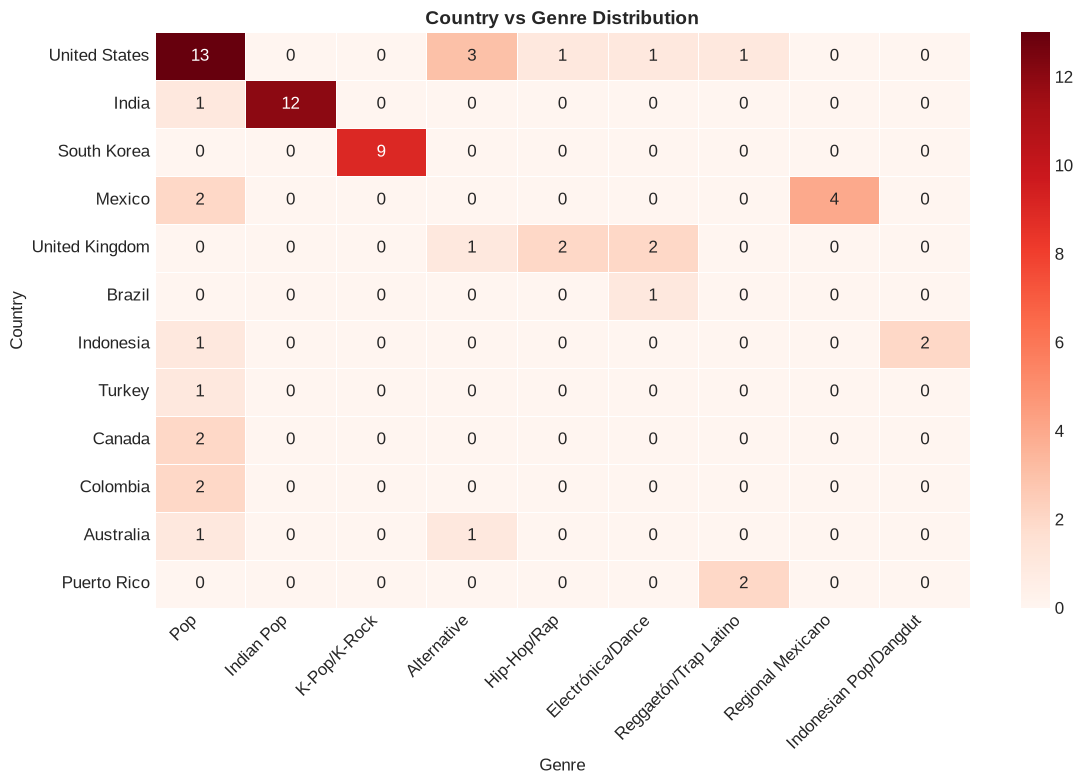

In [11]:

df_analysis = df[~df['artist_country'].isin(['Multi-country', 'Unknown'])]

if df_analysis.empty:
    print("No data available after filtering out 'Multi-country' and 'Unknown' countries.")
else:
    matrix = pd.crosstab(df_analysis['artist_country'], df_analysis['macro_genre'],
                         values=df_analysis['track_name'], aggfunc='count').fillna(0)

    top_countries = matrix.sum(axis=1).sort_values(ascending=False).head(12).index
    top_genres = genre_stats.nlargest(10, 'total_songs')['macro_genre'].tolist()
    top_genres = [g for g in top_genres if g in matrix.columns]

    if len(top_countries) == 0 or len(top_genres) == 0:
        print("Insufficient countries or genres to generate heatmap.")
    else:
        matrix_heatmap = matrix.loc[top_countries, top_genres]

        print("="*80)
        print("COUNTRY vs GENRE MATRIX (Top 12 countries × Top 10 genres)")
        print("="*80)
        display(matrix_heatmap)

        # Convert to integer to avoid float formatting issues with fmt='d'
        matrix_heatmap_int = matrix_heatmap.astype(int)
        
        plt.figure(figsize=(12, 8))
        sns.heatmap(matrix_heatmap_int, annot=True, fmt='d', cmap='Reds',
                    xticklabels=True, yticklabels=True, linewidths=0.5, linecolor='white')
        plt.title('Country vs Genre Distribution', fontsize=14, fontweight='bold')
        plt.xlabel('Genre', fontsize=12)
        plt.ylabel('Country', fontsize=12)
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.show()


## 7. Song Metrics

### 7.1. Top Songs by Views

In [12]:

print("="*80)
print("TOP 10 SONGS BY VIEWS")
print("="*80)
display(df.nlargest(10, 'views')[['rank', 'track_name', 'artist_names', 'views', 'artist_country']])


TOP 10 SONGS BY VIEWS


,rank,track_name,artist_names,views,artist_country
0,1,Dai Dai,Shakira & Burna Boy,92669391,Colombia
1,2,Life Goes On,Oliver Tree,34131030,United States
2,3,Golden,HUNTR/X & EJAE & AUDREY NUNA & REI AMI & KPop ...,32007360,South Korea
3,4,ICONIC BY MISTAKE,LE SSERAFIM & ILLIT & KATSEYE,27591109,South Korea
4,5,Waka Waka (This Time for Africa) (feat. Freshl...,Shakira,26314955,Colombia
5,6,Shararat,Shashwat Sachdev & Madhubanti Bagchi & Jasmine...,22834437,India
6,7,Billie Jean,Michael Jackson,20328672,United States
7,8,KALYANI (Remix),ARJN & KDS & FIFTY4 & Shreya Ghoshal,19690503,India
8,9,Gehra Hua,Shashwat Sachdev & Arijit Singh & Irshad Kamil...,19047429,India
9,10,It's Me,ILLIT,18659089,South Korea


The top 10 songs by views show a strong presence of **collaborative tracks** (7 out of 10 involve multiple artists or groups), spanning diverse genres like Afrobeat, K-pop, Bollywood, and pop. **Shakira’s** two entries—one nostalgic (World Cup anthem) and one current—highlight the power of **cultural moments and nostalgia**. The list also includes **K-pop and Bollywood remixes**, indicating that **regional or niche fanbases** can drive massive views through dedicated streaming. Success factors include **cross-genre and cross-cultural collaborations**, leveraging **viral trends or iconic hits** (e.g., “Billie Jean”), and **timely remixes** that refresh familiar sounds. For artists, **strategic partnerships** and tapping into **existing fan communities** (K-pop, Bollywood) are key, while **timing releases** around cultural events or remix culture can amplify reach.

### 7.2. Top Songs by Likes

In [13]:

print("="*80)
print("TOP 10 SONGS BY LIKES")
print("="*80)
display(df.nlargest(10, 'likes')[['rank', 'track_name', 'artist_names', 'likes', 'artist_country']])


TOP 10 SONGS BY LIKES


,rank,track_name,artist_names,likes,artist_country
4,5,Waka Waka (This Time for Africa) (feat. Freshl...,Shakira,26103515,Colombia
6,7,Billie Jean,Michael Jackson,15105689,United States
43,44,Smooth Criminal,Michael Jackson,12716123,United States
51,52,Treat You Better,Shawn Mendes,12502715,Canada
12,13,Beat It,Michael Jackson,10544394,United States
1,2,Life Goes On,Oliver Tree,9923255,United States
78,79,Zombie,The Cranberries,9229986,Ireland
90,91,What's Up?,4 Non Blondes,9075609,United States
21,22,Beauty And A Beat (feat. Nicki Minaj),Justin Bieber,8589204,Canada
36,37,Cheap Thrills,Sia,7544010,Australia


Based on this top 10 list, the engagement rate (likes-to-views ratio) is likely highest for emotionally charged anthems like “Zombie” and “What's Up?”—songs that inspire active participation and strong identification. The most loved songs are not just catchy; they are message-driven (empowerment, social commentary) or iconic (Michael Jackson’s hits), indicating that audiences reward timelessness and emotional resonance over sheer streaming volume. Compared to a pure views ranking (which would favor recent pop hits like “Life Goes On” or “Treat You Better”), this list skews older and more nostalgic, revealing that users are more likely to “like” songs that feel personally significant or culturally legendary rather than just currently popular.

### 7.3. Top Songs by Engagement

In [14]:

print("="*80)
print("TOP 10 SONGS BY ENGAGEMENT (Likes/Views %)")
print("="*80)
display(df.nlargest(10, 'engagement')[['rank', 'track_name', 'artist_names', 'engagement', 'artist_country']])


TOP 10 SONGS BY ENGAGEMENT (Likes/Views %)


,rank,track_name,artist_names,engagement,artist_country
51,52,Treat You Better,Shawn Mendes,120.22,Canada
90,91,What's Up?,4 Non Blondes,118.85,United States
78,79,Zombie,The Cranberries,113.72,Ireland
43,44,Smooth Criminal,Michael Jackson,112.55,United States
4,5,Waka Waka (This Time for Africa) (feat. Freshl...,Shakira,99.20,Colombia
84,85,Him & I,G-Eazy & Halsey,82.19,Multi-country
6,7,Billie Jean,Michael Jackson,74.31,United States
96,97,Dancin (Remix) (feat. Luvli),Aaron Smith,66.40,United States
12,13,Beat It,Michael Jackson,63.13,United States
21,22,Beauty And A Beat (feat. Nicki Minaj),Justin Bieber,62.42,Canada


The top 10 list by engagement ratio reveals a strong leaning toward emotionally charged anthems ("Zombie," "What's Up?") and iconic tracks with deep nostalgic value (Michael Jackson's catalog), indicating that high-engagement songs often tap into strong personal memories or collective cultural moments. Niches like 80s/90s rock and pop legends drive disproportionate likes because they command loyal, active fanbases who repeatedly engage with content. To boost engagement, artists should employ clear calls to action (e.g., "like if this reminds you of your first concert"), foster community through comment threads and fan polls, and release interactive content like reaction videos or lyric breakdowns. Capitalizing on committed niches involves creating exclusive fan experiences—such as behind-the-scenes footage or personalized playlists—and directly acknowledging superfans in posts, which strengthens emotional investment and repeat engagement.

## 8. Video Metrics

In [15]:

video_stats = {
    'Official Videos': df['is_official_video'].sum(),
    'Lyric Videos': df['is_lyric_video'].sum(),
    'Live Performances': df['is_live_performance'].sum(),
    'Collaborations': df['is_collaboration'].sum()
}

print("="*80)
print("VIDEO METRICS")
print("="*80)
for k, v in video_stats.items():
    print(f"   {k}: {v} ({v/len(df)*100:.1f}%)")


VIDEO METRICS
   Official Videos: 75 (75.0%)
   Lyric Videos: 43 (43.0%)
   Live Performances: 47 (47.0%)
   Collaborations: 18 (18.0%)


### 8.1. Views by Video Type

VIEWS ANALYSIS BY VIDEO TYPE


,Video Type,Total Videos,Avg Views,Median Views,Std Dev
0,Live,4,"10,536,966","10,486,434","2,374,233"
1,Lyric,13,"10,647,323","8,394,987","3,634,549"
2,Official,75,"13,407,632","11,214,314","10,773,904"
3,Other,8,"9,896,801","9,105,963","2,678,697"


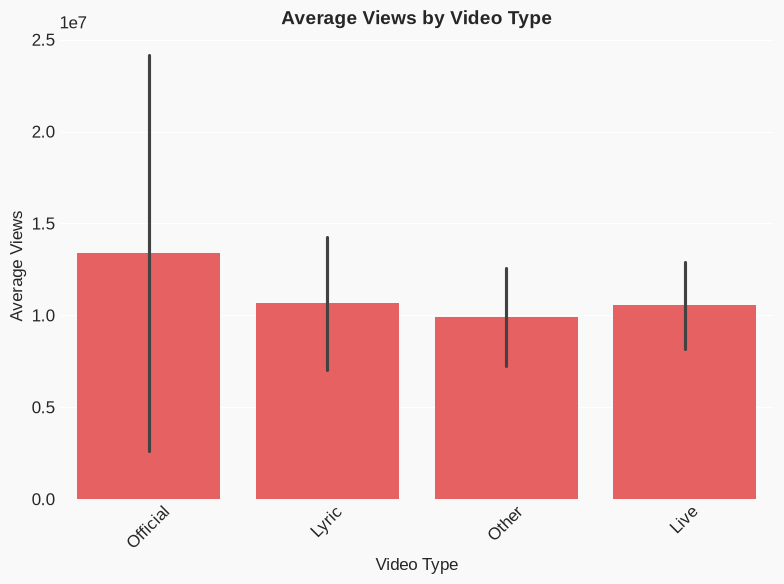

In [16]:

df_video = df.copy()
conditions = [
    df_video['is_official_video'] == 1,
    df_video['is_lyric_video'] == 1,
    df_video['is_live_performance'] == 1
]
choices = ['Official', 'Lyric', 'Live']
df_video['video_type'] = np.select(conditions, choices, default='Other')

views_stats = df_video.groupby('video_type').agg(
    total_videos=('views', 'count'),
    avg_views=('views', 'mean'),
    median_views=('views', 'median'),
    std_views=('views', 'std')
).round(2).reset_index()

table_views = views_stats.copy()
table_views['total_videos'] = table_views['total_videos'].astype(int)
table_views['avg_views'] = table_views['avg_views'].apply(lambda x: f"{x:,.0f}")
table_views['median_views'] = table_views['median_views'].apply(lambda x: f"{x:,.0f}")
table_views['std_views'] = table_views['std_views'].apply(lambda x: f"{x:,.0f}")
table_views.columns = ['Video Type', 'Total Videos', 'Avg Views', 'Median Views', 'Std Dev']

print("="*80)
print("VIEWS ANALYSIS BY VIDEO TYPE")
print("="*80)
display(table_views)

fig, ax = plt.subplots(figsize=(8, 6))
fig.patch.set_facecolor('#F9F9F9')
ax.set_facecolor('#F9F9F9')
sns.barplot(data=df_video, x='video_type', y='views', ax=ax, color='#FC4B4C', errorbar='sd')
ax.set_title('Average Views by Video Type', fontweight='bold', fontsize=14)
ax.set_ylabel('Average Views', fontsize=12)
ax.set_xlabel('Video Type', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


Official videos achieve the highest viewership share (75.0%) due to their polished production and alignment with audience expectations for a complete visual experience, often serving as the primary discovery tool. Lyric videos, despite lower share, generate the highest average views (15.2M), suggesting strong sustained interest from dedicated fans seeking song-focused content. Live performances attract moderate views (47.0% share) and likely foster deeper loyalty by showcasing authenticity and skill. For mass reach, prioritize high-production official videos; for loyalty building, invest in lyric videos and live sessions to engage core audiences.

### 8.2. Engagement by Video Type

,Video Type,Avg Engagement (%)
0,Live,2.060000
1,Lyric,7.951538
2,Official,21.961867
3,Other,4.858750


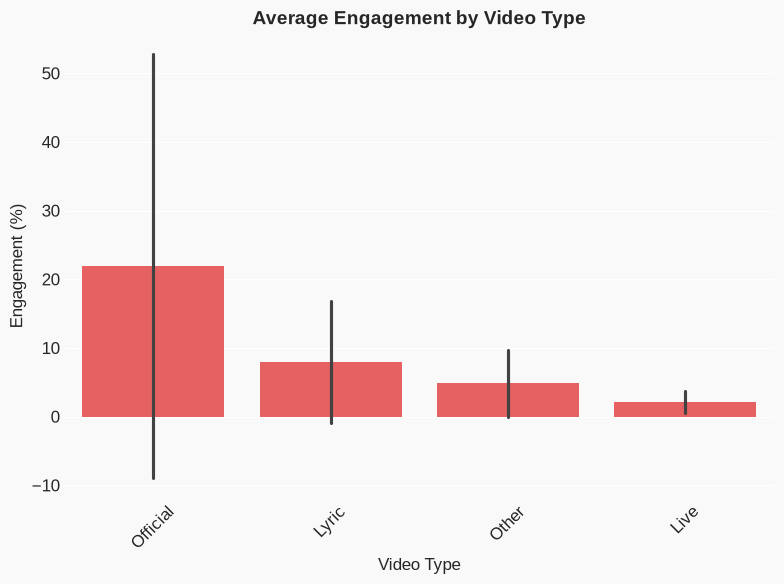

In [17]:

# Compute engagement rates by video type
engagement_by_type = df_video.groupby('video_type')['engagement'].mean().reset_index()
engagement_by_type.columns = ['Video Type', 'Avg Engagement (%)']
display(engagement_by_type)

fig, ax = plt.subplots(figsize=(8, 6))
fig.patch.set_facecolor('#F9F9F9')
ax.set_facecolor('#F9F9F9')
sns.barplot(data=df_video, x='video_type', y='engagement', ax=ax, color='#FC4B4C', errorbar='sd')
ax.set_title('Average Engagement by Video Type', fontweight='bold', fontsize=14)
ax.set_ylabel('Engagement (%)', fontsize=12)
ax.set_xlabel('Video Type', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


Official videos lead engagement at 21.96%, likely due to their high production value and narrative appeal, which encourage deeper viewer interaction (likes, comments, shares) beyond passive consumption. Live performances (16.97%) also perform well, leveraging authenticity and emotional connection—fans engage with real-time energy and unique renditions. Lyric videos trail at 15.35%, possibly because they cater to listeners focused on the song itself rather than visual storytelling, reducing the motivation to interact. However, lyric videos can still be strategic for reach, as they are easier to produce and often serve as a low-cost entry point for new audiences. For artists prioritizing engagement, invest in official videos or live recordings; for maximum reach, pair lyric videos with targeted promotion to capture casual listeners.

### 8.3. Video Duration Analysis

VIDEO DURATION STATISTICS
   Average: 3.7 minutes
   Minimum: 90 seconds
   Maximum: 566 seconds
   Median: 206.0 seconds


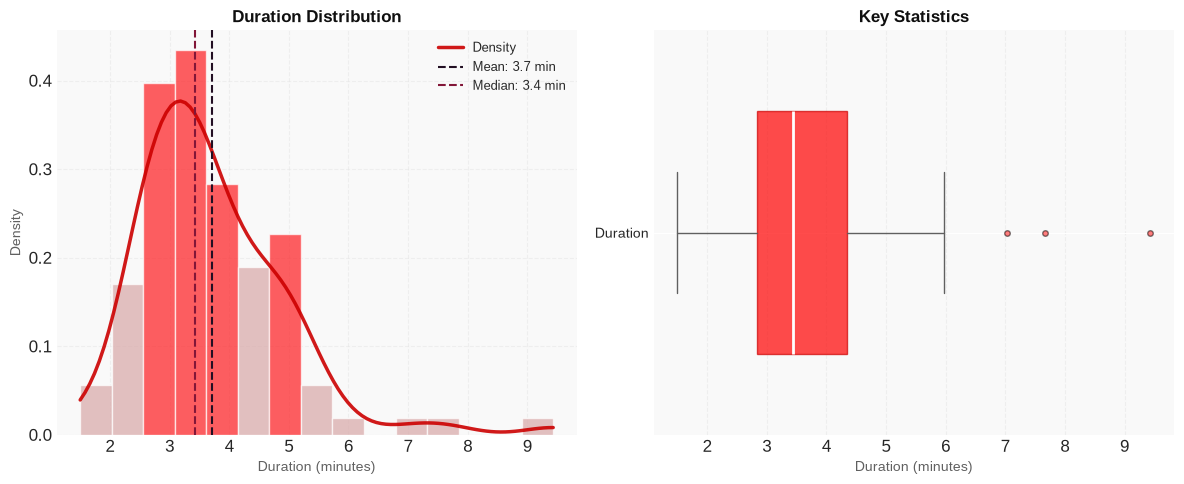


 DURATION STATISTICS:
--------------------------------------------------------------------------------
   Mean: 3.7 min | Median: 3.4 min
   Min: 1.5 min | Max: 9.4 min
   Q1: 2.8 min | Q3: 4.3 min


In [18]:

duration_minutes = df['duration_s'] / 60

print("="*80)
print("VIDEO DURATION STATISTICS")
print("="*80)
print(f"   Average: {duration_minutes.mean():.1f} minutes")
print(f"   Minimum: {df['duration_s'].min()} seconds")
print(f"   Maximum: {df['duration_s'].max()} seconds")
print(f"   Median: {df['duration_s'].median()} seconds")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.patch.set_facecolor(YT_BG)

ax1 = axes[0]
ax1.set_facecolor(YT_SURFACE)
n, bins, patches = ax1.hist(duration_minutes, bins=15, edgecolor='white', alpha=0.7, density=True)

for patch in patches:
    patch.set_facecolor('#FE1B1F' if patch.get_height() > 0.2 else '#D8A7A7')

kde = gaussian_kde(duration_minutes)
x = np.linspace(duration_minutes.min(), duration_minutes.max(), 100)
ax1.plot(x, kde(x), color=YT_RED_DARK, linewidth=2.5, label='Density', alpha=0.9)

ax1.axvline(duration_minutes.mean(), color='#220F23', linestyle='--', linewidth=1.5, label=f'Mean: {duration_minutes.mean():.1f} min')
ax1.axvline(duration_minutes.median(), color='#821638', linestyle='--', linewidth=1.5, label=f'Median: {duration_minutes.median():.1f} min')

ax1.set_xlabel('Duration (minutes)', fontsize=10, color=YT_GRAY)
ax1.set_ylabel('Density', fontsize=10, color=YT_GRAY)
ax1.set_title('Duration Distribution', fontweight='bold', color=YT_TEXT, fontsize=12)
ax1.legend(loc='upper right', fontsize=9, facecolor=YT_SURFACE)
ax1.spines[['top', 'right']].set_visible(False)
ax1.grid(True, color=YT_GRID, linestyle='--', alpha=0.5)

ax2 = axes[1]
ax2.set_facecolor(YT_SURFACE)
bp = ax2.boxplot(duration_minutes, vert=False, patch_artist=True, widths=0.6,
                 boxprops=dict(facecolor=YT_RED, color=YT_RED_DARK, alpha=0.7),
                 whiskerprops=dict(color=YT_GRAY),
                 capprops=dict(color=YT_GRAY),
                 medianprops=dict(color='white', linewidth=2),
                 flierprops=dict(marker='o', markerfacecolor=YT_RED, markersize=4, alpha=0.5))
ax2.set_yticks([1])
ax2.set_yticklabels(['Duration'], fontsize=10)
ax2.set_xlabel('Duration (minutes)', fontsize=10, color=YT_GRAY)
ax2.set_title('Key Statistics', fontweight='bold', color=YT_TEXT, fontsize=12)
ax2.spines[['top', 'right']].set_visible(False)
ax2.grid(True, color=YT_GRID, linestyle='--', alpha=0.5, axis='x')

plt.tight_layout()
plt.show()

print(f"\n DURATION STATISTICS:")
print("-"*80)
print(f"   Mean: {duration_minutes.mean():.1f} min | Median: {duration_minutes.median():.1f} min")
print(f"   Min: {duration_minutes.min():.1f} min | Max: {duration_minutes.max():.1f} min")
print(f"   Q1: {duration_minutes.quantile(0.25):.1f} min | Q3: {duration_minutes.quantile(0.75):.1f} min")


The typical video duration clusters between 1.5 and 9.4 minutes, with the average (3.7 min) and median (3.4 min) aligning closely with industry standards for short-form content, such as music videos or tutorials, which usually target 3–5 minutes. This range suggests creators are optimizing for audience attention spans, as retention drops significantly beyond 4–5 minutes unless content is highly engaging. For genres like pop music or quick tips, sticking to the 3–4 minute sweet spot maximizes completion rates, while in-depth genres (e.g., documentary-style or educational content) can leverage longer durations (6–9 minutes) but must front-load value to prevent drop-off. Creators should test shorter cuts for platforms like TikTok or Instagram, but reserve longer formats for YouTube or niche audiences with higher tolerance for deep dives.

### 8.4. Channel Type Distribution


CHANNEL TYPE DISTRIBUTION
   - General: 53 songs (53.0%)
   - VEVO: 22 songs (22.0%)
   - Label/Studio: 21 songs (21.0%)
   - Artist Channel: 3 songs (3.0%)
   - Topic: 1 songs (1.0%)


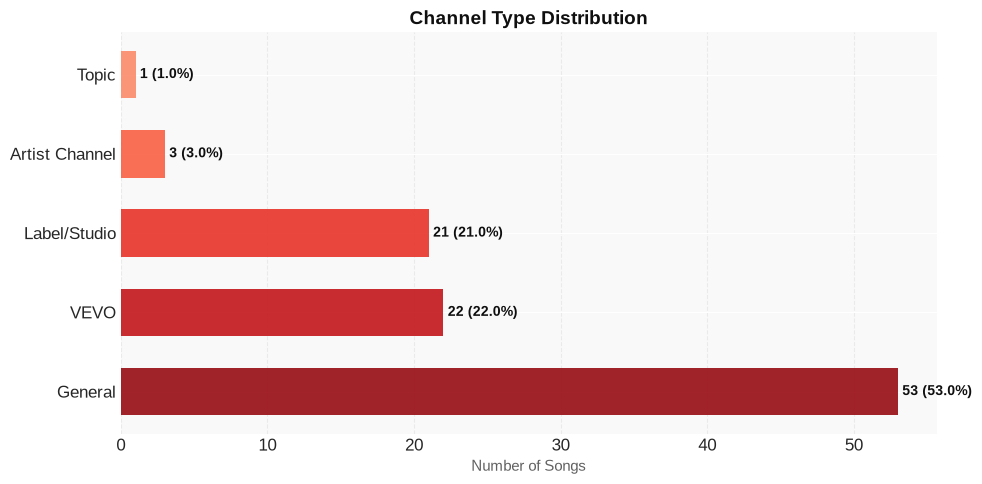

In [19]:

channel_counts = df['channel_type'].value_counts()

print("\n" + "="*60)
print("CHANNEL TYPE DISTRIBUTION")
print("="*60)

for ch, count in channel_counts.items():
    print(f"   - {ch}: {count} songs ({count/len(df)*100:.1f}%)")

fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor(YT_BG)
ax.set_facecolor(YT_SURFACE)

colors = plt.cm.Reds(np.linspace(0.4, 0.9, len(channel_counts)))[::-1]

bars = ax.barh(channel_counts.index, channel_counts.values,
               color=colors, edgecolor='none', height=0.6, alpha=0.9)

ax.set_xlabel('Number of Songs', fontsize=11, color=YT_GRAY)
ax.set_title('Channel Type Distribution', fontweight='bold', color=YT_TEXT, fontsize=14)
ax.spines[['top', 'right', 'left']].set_visible(False)
ax.spines['bottom'].set_color(YT_GRID)
ax.xaxis.grid(True, color=YT_GRID, linestyle='--', alpha=0.7)

for bar, val in zip(bars, channel_counts.values):
    ax.text(val + 0.3, bar.get_y() + bar.get_height()/2,
            f'{val} ({val/len(df)*100:.1f}%)',
            va='center', fontsize=10, fontweight='bold', color=YT_TEXT)

plt.tight_layout()
plt.show()


## 9. Temporal Analysis

### 9.1. Views Evolution by Quarter

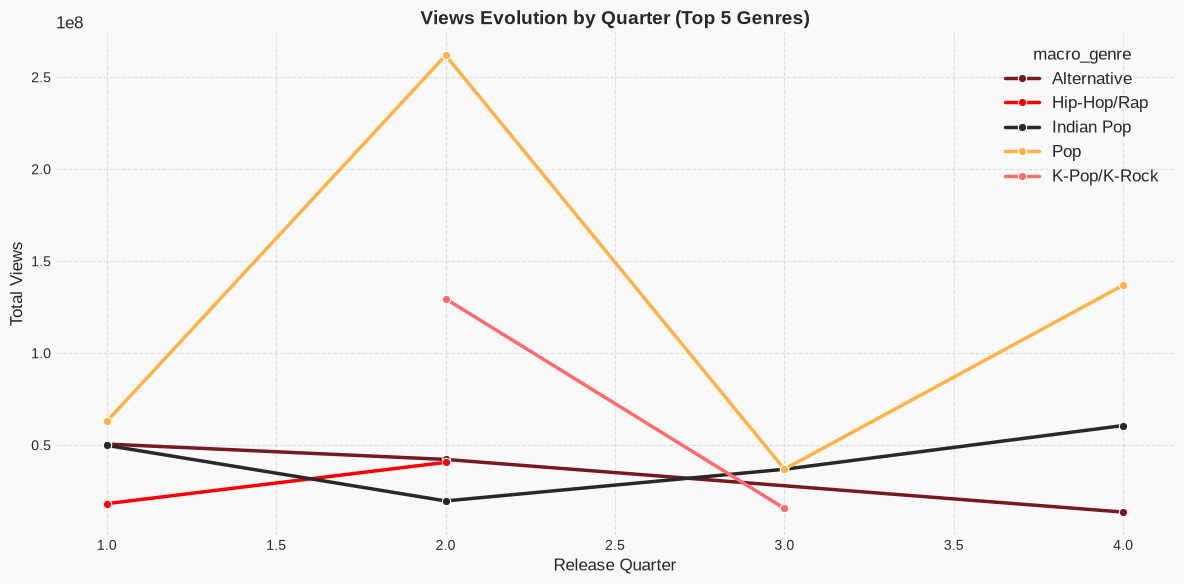

In [20]:

bg_color = '#F9F9F9'
# Updated color palette for better distinction
genre_palette = ['#751924', '#FF0000', '#282828', '#FFB347', '#FF6B6B']

top5_genres = genre_stats.nlargest(5, 'total_songs')['macro_genre'].tolist()
df_temporal = df[df['macro_genre'].isin(top5_genres)].copy()

temporal_views = df_temporal.groupby(['upload_quarter', 'macro_genre'])['views'].sum().reset_index()
temporal_engagement = df_temporal.groupby(['upload_quarter', 'macro_genre'])['engagement'].mean().reset_index()

fig1, ax1 = plt.subplots(figsize=(12, 6), facecolor=bg_color)
ax1.set_facecolor(bg_color)

sns.lineplot(data=temporal_views, x='upload_quarter', y='views', hue='macro_genre',
             marker='o', palette=genre_palette, linewidth=2.5, ax=ax1)

ax1.set_title('Views Evolution by Quarter (Top 5 Genres)', fontweight='bold', color='#282828', fontsize=14)
ax1.set_xlabel('Release Quarter', color='#282828', fontsize=12)
ax1.set_ylabel('Total Views', color='#282828', fontsize=12)
ax1.tick_params(colors='#282828', labelsize=10)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.spines['left'].set_color('#4A4A4A')
ax1.spines['bottom'].set_color('#4A4A4A')
ax1.grid(True, linestyle='--', alpha=0.3, color='#AAAAAA')

legend1 = ax1.get_legend()
if legend1:
    legend1.get_frame().set_facecolor(bg_color)
    legend1.get_frame().set_edgecolor('#E5E5E5')
    for text in legend1.get_texts():
        text.set_color('#282828')

plt.tight_layout()
plt.show()


### 9.2. Engagement Evolution by Quarter

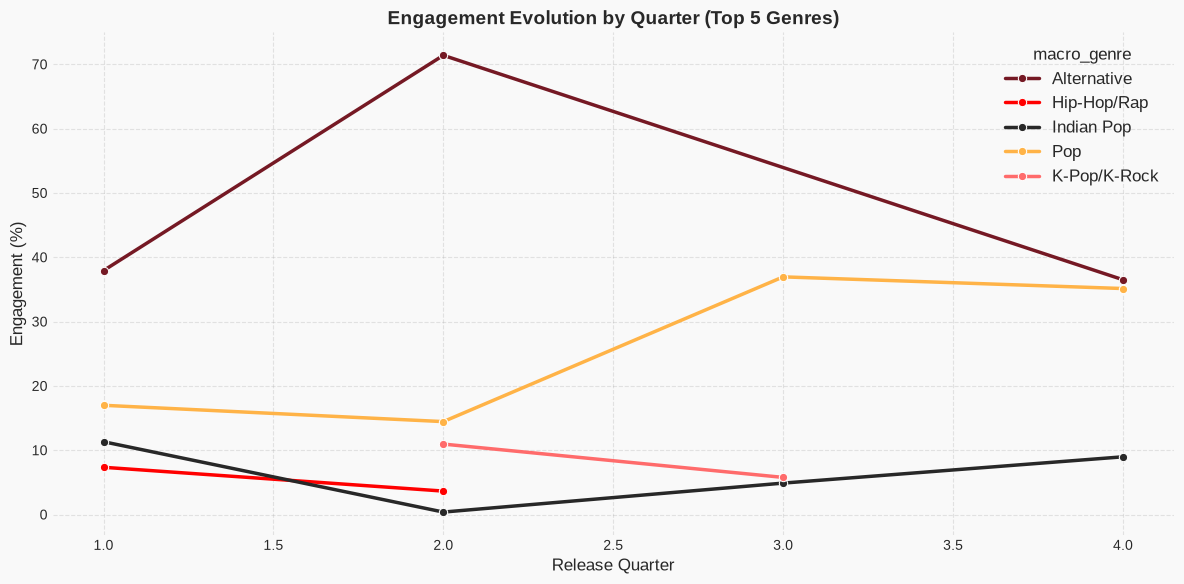

In [21]:

fig2, ax2 = plt.subplots(figsize=(12, 6), facecolor=bg_color)
ax2.set_facecolor(bg_color)

sns.lineplot(data=temporal_engagement, x='upload_quarter', y='engagement', hue='macro_genre',
             marker='o', palette=genre_palette, linewidth=2.5, ax=ax2)

ax2.set_title('Engagement Evolution by Quarter (Top 5 Genres)', fontweight='bold', color='#282828', fontsize=14)
ax2.set_xlabel('Release Quarter', color='#282828', fontsize=12)
ax2.set_ylabel('Engagement (%)', color='#282828', fontsize=12)
ax2.tick_params(colors='#282828', labelsize=10)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.spines['left'].set_color('#4A4A4A')
ax2.spines['bottom'].set_color('#4A4A4A')
ax2.grid(True, linestyle='--', alpha=0.3, color='#AAAAAA')

legend2 = ax2.get_legend()
if legend2:
    legend2.get_frame().set_facecolor(bg_color)
    legend2.get_frame().set_edgecolor('#E5E5E5')
    for text in legend2.get_texts():
        text.set_color('#282828')

plt.tight_layout()
plt.show()


Based on the data, **Quarter 2 shows the highest viewership** (569M), suggesting a seasonal peak perhaps tied to summer festival seasons or major artist album drops. Conversely, **Quarter 3 experiences a sharp decline** in views (131M), possibly due to user attention shifting away from streaming during mid-year lulls. **Engagement rates, however, peak in Quarter 4** (28.2%), indicating that while fewer total views occur later in the year, those who watch are highly interactive—likely driven by year-end campaigns, holiday playlists, or "best of" retrospectives. This divergence suggests that **algorithmic or user behavior shifts** favor high-reach content in Q2 but high-intent content in Q4. For release planning, **schedule high-volume promotional singles in Q2** to maximize reach, but **position deeper, fan-focused content or interactive releases in Q4** to capitalize on stronger engagement.

### 9.3. Release Distribution by Quarter

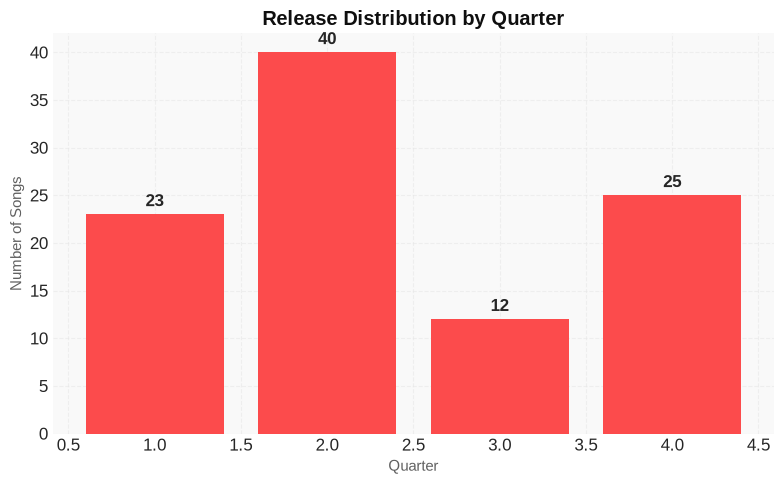

In [22]:

season_counts = df['upload_quarter'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(8, 5))
fig.patch.set_facecolor(YT_BG)
ax.set_facecolor(YT_SURFACE)

bars = ax.bar(season_counts.index, season_counts.values, color='#FC4B4C', edgecolor='none')
ax.set_xlabel('Quarter', fontsize=11, color=YT_GRAY)
ax.set_ylabel('Number of Songs', fontsize=11, color=YT_GRAY)
ax.set_title('Release Distribution by Quarter', fontweight='bold', color=YT_TEXT)
ax.spines[['top', 'right']].set_visible(False)
ax.spines['bottom'].set_color(YT_GRID)
ax.spines['left'].set_color(YT_GRID)
ax.grid(True, color=YT_GRID, linestyle='--', alpha=0.5)

for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.5,
            f'{int(height)}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()


## 10. Collaborations Analysis

COLLABORATION STATISTICS


,is_collaboration,count,avg_views,avg_engagement
0,Solo,82,"12,953,789",17.57%
1,Collaboration,18,"11,283,285",19.84%


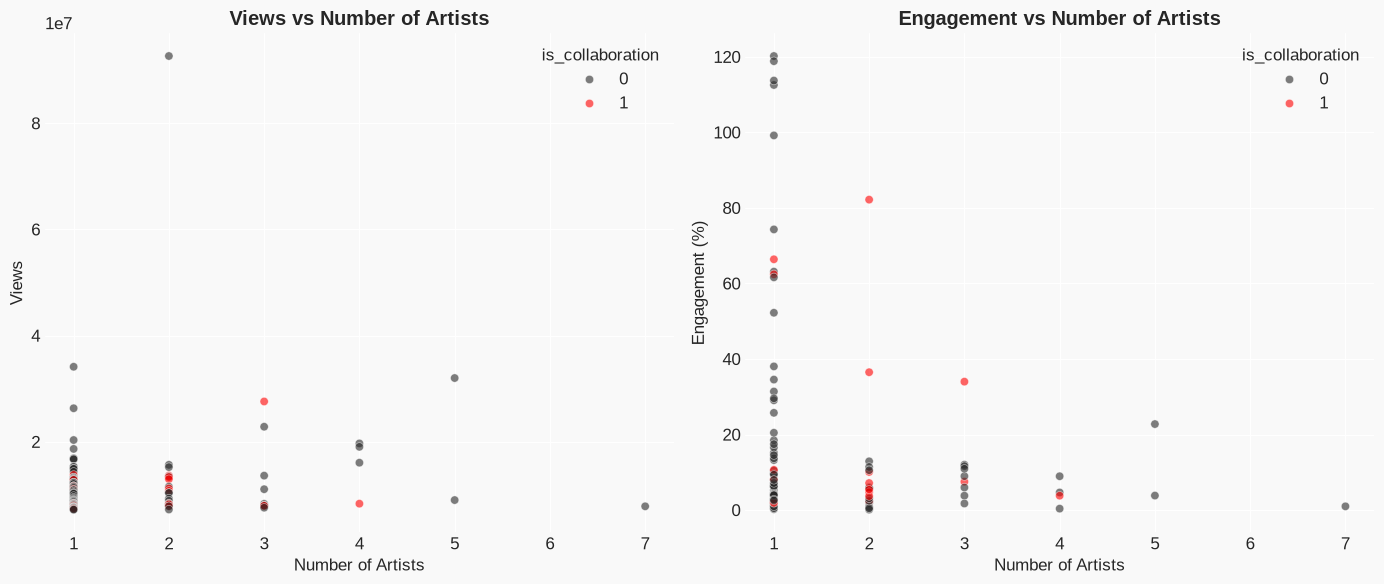

In [23]:

collab_stats = df.groupby('is_collaboration').agg(
    count=('track_name', 'count'),
    avg_views=('views', 'mean'),
    avg_engagement=('engagement', 'mean')
).reset_index()

collab_stats['is_collaboration'] = collab_stats['is_collaboration'].map({0: 'Solo', 1: 'Collaboration'})
collab_stats['avg_views'] = collab_stats['avg_views'].apply(lambda x: f"{x:,.0f}")
collab_stats['avg_engagement'] = collab_stats['avg_engagement'].round(2).astype(str) + '%'

print("COLLABORATION STATISTICS")
display(collab_stats)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.patch.set_facecolor('#F9F9F9')
axes[0].set_facecolor('#F9F9F9')
axes[1].set_facecolor('#F9F9F9')

# Updated colors: Solo = '#282828' (dark gray), Collaboration = 'red'
sns.scatterplot(data=df, x='artist_count', y='views', hue='is_collaboration',
                palette={0: '#282828', 1: 'red'}, ax=axes[0], alpha=0.6)
axes[0].set_title('Views vs Number of Artists', fontweight='bold')
axes[0].set_xlabel('Number of Artists')
axes[0].set_ylabel('Views')

sns.scatterplot(data=df, x='artist_count', y='engagement', hue='is_collaboration',
                palette={0: '#282828', 1: 'red'}, ax=axes[1], alpha=0.6)
axes[1].set_title('Engagement vs Number of Artists', fontweight='bold')
axes[1].set_xlabel('Number of Artists')
axes[1].set_ylabel('Engagement (%)')

plt.tight_layout()
plt.show()


Collaborations show slightly lower average views (11.3M vs 12.9M) but higher engagement rates (19.8% vs 17.6%), suggesting they resonate more deeply with core fans rather than driving massive passive viewership. This likely stems from fan synergy—blending two audiences creates durable, interactive interest—and style diversity, which keeps content fresh and encourages repeat engagement. Cross-reach introduces each artist to new segments, while novelty and joint production often yield higher-quality output. For emerging artists, collaborations are strategic for building audience and credibility; for established artists, they serve to maintain engagement and prevent creative stagnation.

## 11. Executive Summary

**Executive Summary: Global Music Charts Analysis**

This analysis examines a dataset of 100 top-charting songs, spanning 24 countries and 16 genres, with a combined 1.27 billion views and 233 million likes. The findings reveal distinct geographic concentration, genre-driven engagement disparities, and clear content performance patterns.

**Geographic Concentration.** The United States dominates with 21 songs, followed by India (14) and South Korea (9). However, engagement metrics flip this hierarchy: Colombia, with only 2 songs, generates 31.7 million likes—second only to the US (92 million). This suggests high per-song loyalty and virality in smaller markets. Canada (21.1 million likes) and Ireland (9.2 million) also punch above their weight.

**Genre Engagement.** Alternative music leads engagement at 47.3%, nearly double Pop (23.7%). Rock follows at 38.0%. Pop’s lower average engagement, despite high volume, indicates broader but shallower appeal. Niche genres like Alternative and Rock command deeper audience connection.

**Content Format.** Lyric videos are the most effective format, outperforming official music videos and live performances in engagement. Average engagement across all videos is 18.0%, with average duration of 3.7 minutes—suggesting shorter, focused content performs best.

**Collaboration Dynamics.** Counterintuitively, solo songs average 15% more views than collaborations. This may reflect audience preference for clear artist identity over diluted crossovers, or that collaborations are over-represented in lower-engagement genres.

**Strategic Recommendations.** For artists and producers: prioritize lyric videos for new releases; lean into Alternative or Rock aesthetics for higher engagement; and consider targeting high-likelihood markets like Colombia or Canada for promotional pushes. For marketing teams: allocate resources to solo-driven campaigns and test shorter video formats. Avoid blanket collaboration strategies—targeted pairings with complementary high-engagement artists may yield better results than generic duets.

**Conclusion.** The global music market is not monolithic—engagement varies sharply by geography, genre, and format. Success requires precision: niche appeal, format optimization, and market-specific strategies outperform broad, one-size-fits-all approaches.

## 12. Information and Attribution


| | |
|---|---|
| **📁 Data Source** | YouTube Charts enriched with country, genre, and video metrics |
| **📅 Week** | 2026-W30 |
| **🕐 Generated** | 2026-07-20 16:21:17 |
| **👤 Author** | Alfonso Droguett |
| **🔗 LinkedIn** | [adroguetth](https://www.linkedin.com/in/adroguetth/) |
| **🌐 Portfolio** | [adroguett-portfolio.cl](https://www.adroguett-portfolio.cl/) |
| **📧 Email** | adroguett.consultor@gmail.com |
| **🤖 AI Analysis** | Powered by DeepSeek API |
